In [3]:
# ==========================================
# CODE 1 / NOTEBOOK 1
# OVERVIEW OF MAIB INCIDENT DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. SETTINGS
# -----------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)



In [4]:
# -----------------------------
# 2. LOAD CLEANED DATA
# -----------------------------
df = pd.read_csv("occurrences_cleaned.csv")

In [5]:
# -----------------------------
# 3. BASIC CHECKS
# -----------------------------
print("Dataset shape:", df.shape)
print("\nColumns:\n")
print(df.columns.tolist())

Dataset shape: (8599, 37)

Columns:

['occurrence_id', 'local_date_main_event', 'date_main_event_unconfirmed', 'year_reported', 'occurrence_severity', 'main_event_l1', 'main_event_l2', 'main_event_l3', 'not_vessel_operations', 'short_description', 'description', 'national_keywords', 'emcip_keywords', 'sar_intervention', 'state_reporting', 'occurrence_location', 'coastal_state_affected', 'national_location_l1', 'national_location_l2', 'latitude', 'longitude', 'lat_long_unknown', 'port_of_accident_l1', 'port_of_accident_l2', 'natural_light', 'sea_state', 'visibility', 'weather', 'wind_force', 'publication_date', 'publication_no', 'publication_type', 'published_report_website_link', 'occurrence_record_modified_on', 'last_updated_at', 'occurrences_reported_from', 'occurrences_reported_to']


In [6]:
# -----------------------------
# 4. DATE HANDLING
# -----------------------------
# local_date_main_event is the main event date field in the dataset
df["local_date_main_event"] = pd.to_datetime(df["local_date_main_event"], errors="coerce")

# create derived time fields
df["event_year"] = df["local_date_main_event"].dt.year
df["event_month"] = df["local_date_main_event"].dt.month
df["event_month_name"] = df["local_date_main_event"].dt.month_name()

In [7]:
# -----------------------------
# 5. HIGH-LEVEL DATASET SUMMARY
# -----------------------------
print("\n===== DATASET SUMMARY =====")
print("Total number of incidents:", len(df))
print("Total number of columns:", df.shape[1])
print("Earliest event date:", df["local_date_main_event"].min())
print("Latest event date:", df["local_date_main_event"].max())
print("Number of unique years:", df["event_year"].nunique())
print("Number of unique severity labels:", df["occurrence_severity"].nunique())
print("Number of unique broad incident types (main_event_l1):", df["main_event_l1"].nunique())


===== DATASET SUMMARY =====
Total number of incidents: 8599
Total number of columns: 40
Earliest event date: 2018-03-01 00:00:00
Latest event date: 2025-12-01 00:00:00
Number of unique years: 8
Number of unique severity labels: 4
Number of unique broad incident types (main_event_l1): 13


In [8]:
# -----------------------------
# 6. MISSING VALUES OVERVIEW
# -----------------------------
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df)) * 100

print("\n===== TOP 20 COLUMNS BY MISSING VALUES =====")
print(missing_summary.head(20))


===== TOP 20 COLUMNS BY MISSING VALUES =====
                           column  missing_count  missing_pct
0                  publication_no           8545    99.372020
1   published_report_website_link           8543    99.348761
2                publication_type           8541    99.325503
3                publication_date           8541    99.325503
4                  emcip_keywords           8474    98.546343
5               national_keywords           8467    98.464938
6                   main_event_l3           8290    96.406559
7                lat_long_unknown           8264    96.104198
8             port_of_accident_l2           5678    66.030934
9             port_of_accident_l1           5348    62.193278
10                  main_event_l2           4351    50.598907
11           national_location_l2           1432    16.653099
12           national_location_l1           1150    13.373648
13                  main_event_l1              2     0.023259
14                      

In [9]:
# -----------------------------
# 7. INCIDENTS PER YEAR
# -----------------------------
yearly_counts = (
    df.dropna(subset=["event_year"])
    .groupby("event_year")
    .size()
    .reset_index(name="count")
    .sort_values("event_year")
)

print("\n===== YEARLY INCIDENT COUNTS =====")
print(yearly_counts)


===== YEARLY INCIDENT COUNTS =====
   event_year  count
0        2018      3
1        2019     18
2        2020   1215
3        2021   1499
4        2022   1256
5        2023   1592
6        2024   1514
7        2025   1502


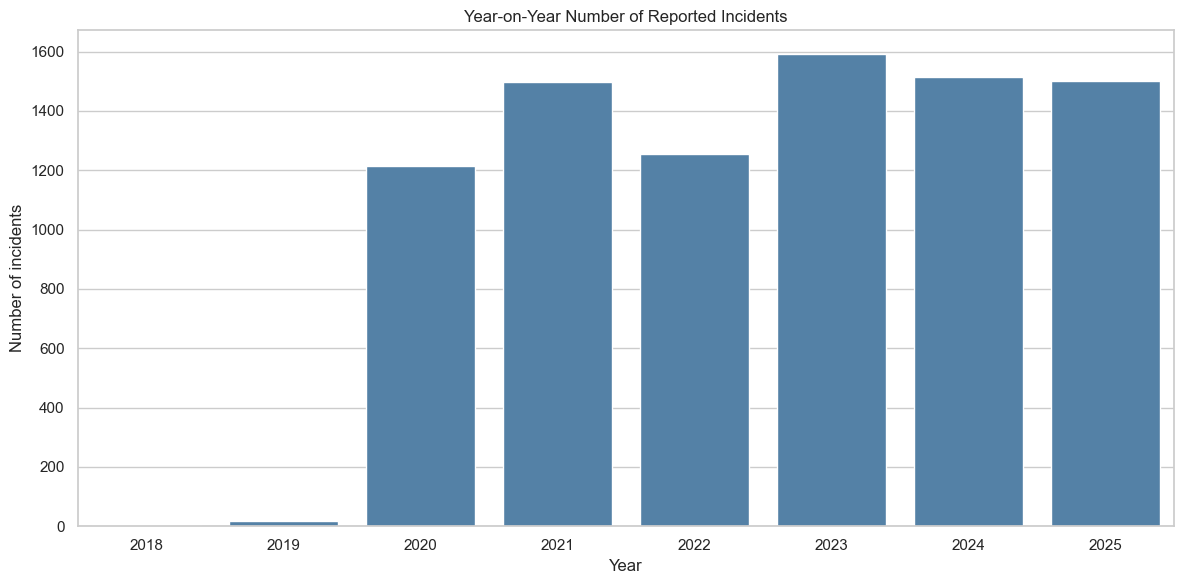

In [10]:
# -----------------------------
# 8. PLOT: YEAR-ON-YEAR INCIDENT COUNTS
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=yearly_counts,
    x="event_year",
    y="count",
    color="steelblue"
)
plt.title("Year-on-Year Number of Reported Incidents")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.tight_layout()
plt.show()

In [11]:
# -----------------------------
# 9. SEVERITY DISTRIBUTION
# -----------------------------
severity_counts = (
    df["occurrence_severity"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

severity_counts.columns = ["occurrence_severity", "count"]

print("\n===== SEVERITY DISTRIBUTION =====")
print(severity_counts)


===== SEVERITY DISTRIBUTION =====
  occurrence_severity  count
0     Marine Incident   4759
1        Less Serious   3116
2             Serious    426
3        Very Serious    298


In [12]:
# -----------------------------
# 10. ORDER SEVERITY CATEGORIES
# -----------------------------
severity_order = [
    "Marine Incident",
    "Less Serious",
    "Serious",
    "Very Serious",

]

severity_counts["occurrence_severity"] = pd.Categorical(
    severity_counts["occurrence_severity"],
    categories=severity_order,
    ordered=True
)

severity_counts = severity_counts.sort_values("occurrence_severity")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2444\305143321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


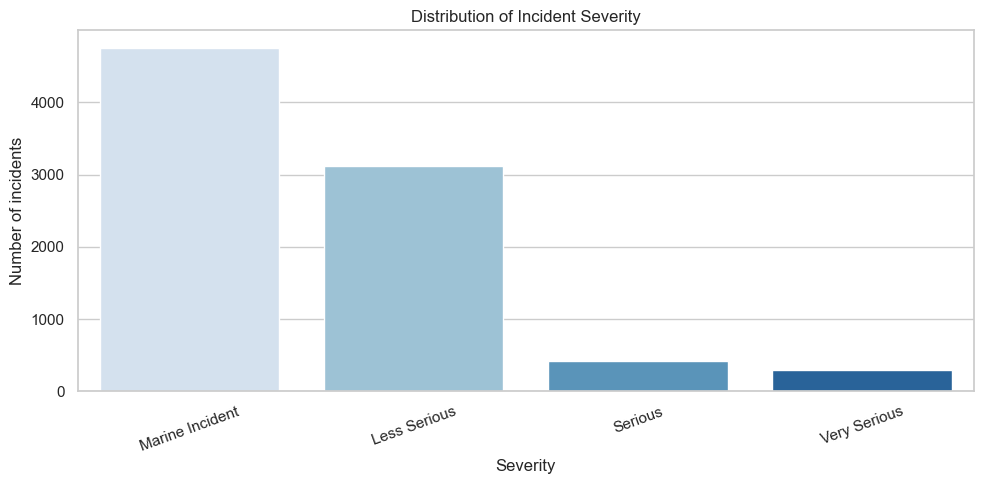

In [16]:
# -----------------------------
# 11. PLOT: SEVERITY DISTRIBUTION
# -----------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=severity_counts,
    x="occurrence_severity",
    y="count",
    palette="Blues"
)
plt.title("Distribution of Incident Severity")
plt.xlabel("Severity")
plt.ylabel("Number of incidents")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [17]:
# -----------------------------
# 12. BROAD INCIDENT TYPE DISTRIBUTION
# -----------------------------
type_counts = (
    df["main_event_l1"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

type_counts.columns = ["main_event_l1", "count"]

print("\n===== TOP BROAD INCIDENT TYPES =====")
print(type_counts.head(15))


===== TOP BROAD INCIDENT TYPES =====
                 main_event_l1  count
0        Accident to person(s)   2381
1   Damage / Loss Of Equipment   1910
2              Loss Of Control   1342
3        Grounding / Stranding    866
4                      Contact    640
5                    Collision    526
6             Fire / Explosion    462
7        Flooding / Foundering    296
8          Capsizing / Listing    157
9                 Hull Failure     10
10        Heavy Weather Damage      3
11        Non-accidental Event      3
12                     Unknown      2
13                     Missing      1


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2444\234102350.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


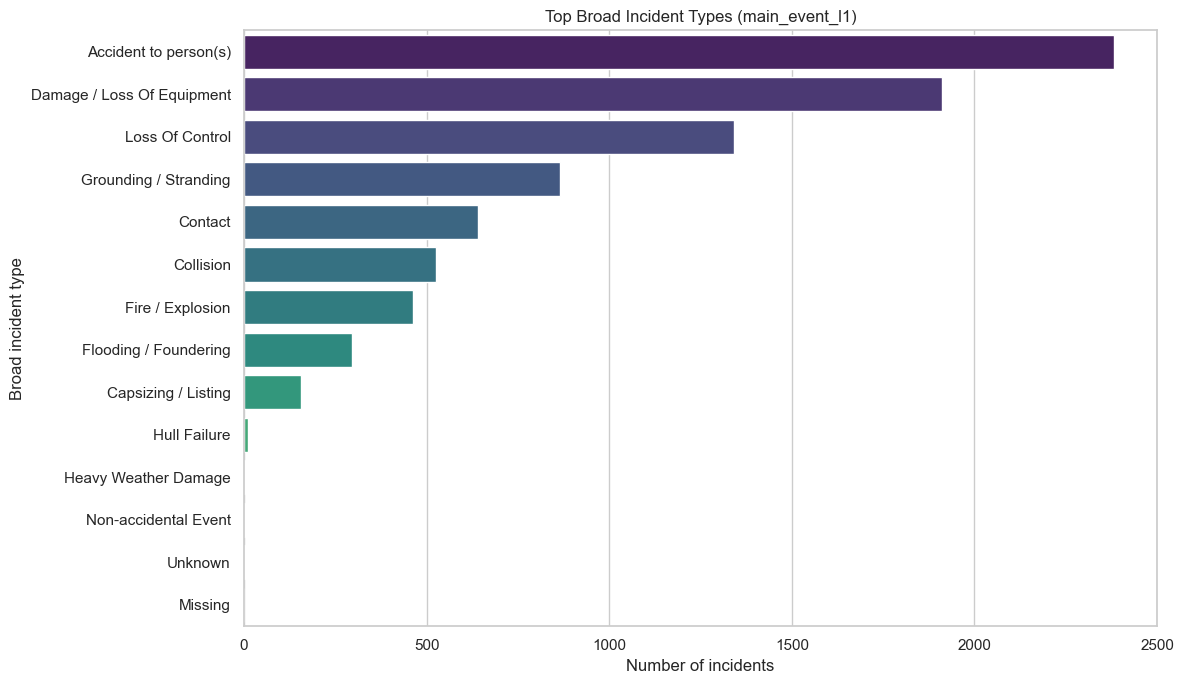

In [18]:
# -----------------------------
# 13. PLOT: TOP BROAD INCIDENT TYPES
# -----------------------------
top_types = type_counts.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_types,
    y="main_event_l1",
    x="count",
    palette="viridis"
)
plt.title("Top Broad Incident Types (main_event_l1)")
plt.xlabel("Number of incidents")
plt.ylabel("Broad incident type")
plt.tight_layout()
plt.show()

In [19]:
# -----------------------------
# 14. YEAR-ON-YEAR INCIDENTS BY BROAD TYPE
# -----------------------------
# keep top 6 categories, rest grouped as Other
top_6_types = df["main_event_l1"].value_counts().head(6).index.tolist()

df["main_event_l1_grouped"] = np.where(
    df["main_event_l1"].isin(top_6_types),
    df["main_event_l1"],
    "Other"
)

year_type_counts = (
    df.dropna(subset=["event_year"])
    .groupby(["event_year", "main_event_l1_grouped"])
    .size()
    .reset_index(name="count")
)

print("\n===== YEAR-ON-YEAR INCIDENTS BY BROAD TYPE =====")
print(year_type_counts.head(20))


===== YEAR-ON-YEAR INCIDENTS BY BROAD TYPE =====
    event_year       main_event_l1_grouped  count
0         2018       Accident to person(s)      1
1         2018  Damage / Loss Of Equipment      2
2         2019       Accident to person(s)      3
3         2019                   Collision      6
4         2019                     Contact      2
5         2019  Damage / Loss Of Equipment      4
6         2019       Grounding / Stranding      2
7         2019             Loss Of Control      1
8         2020       Accident to person(s)    289
9         2020                   Collision     75
10        2020                     Contact    128
11        2020  Damage / Loss Of Equipment    112
12        2020       Grounding / Stranding    146
13        2020             Loss Of Control    292
14        2020                       Other    173
15        2021       Accident to person(s)    356
16        2021                   Collision     76
17        2021                     Contact    107


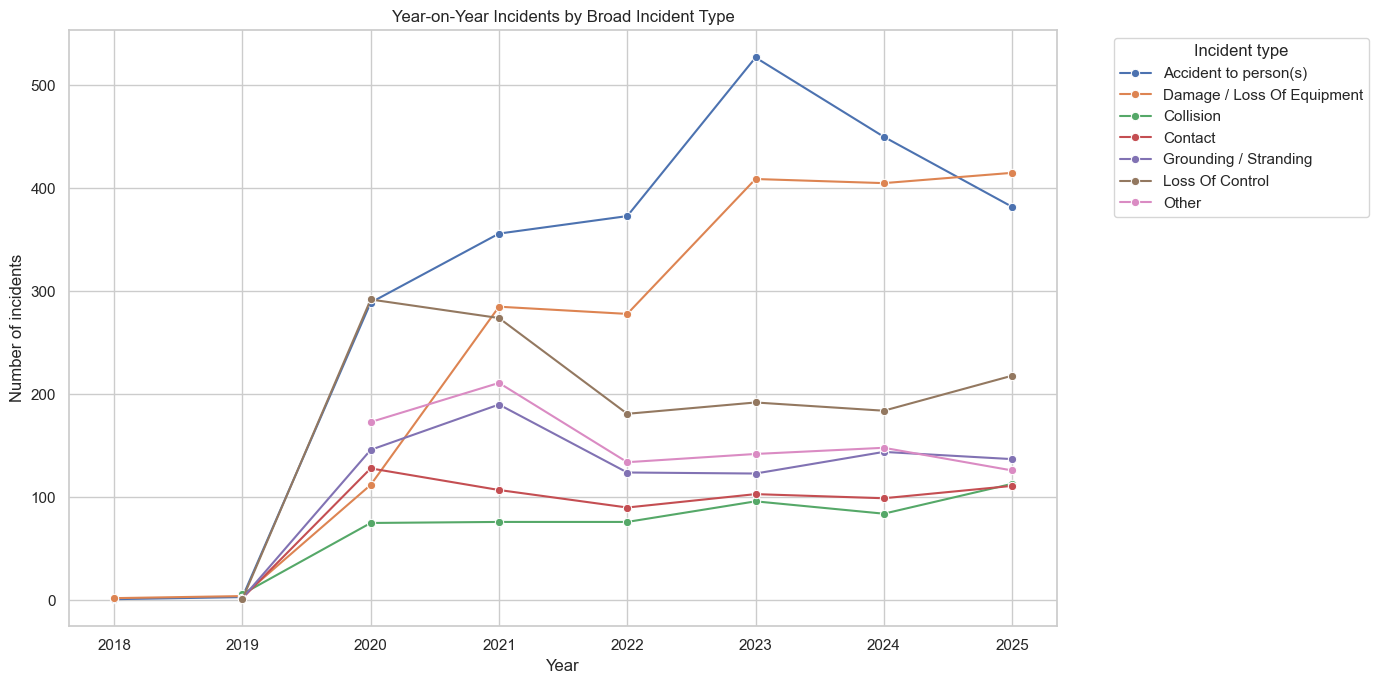

In [20]:
# -----------------------------
# 15. PLOT: LINE CHART FOR YEARLY INCIDENTS BY TYPE
# -----------------------------
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=year_type_counts,
    x="event_year",
    y="count",
    hue="main_event_l1_grouped",
    marker="o"
)

plt.title("Year-on-Year Incidents by Broad Incident Type")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.legend(title="Incident type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

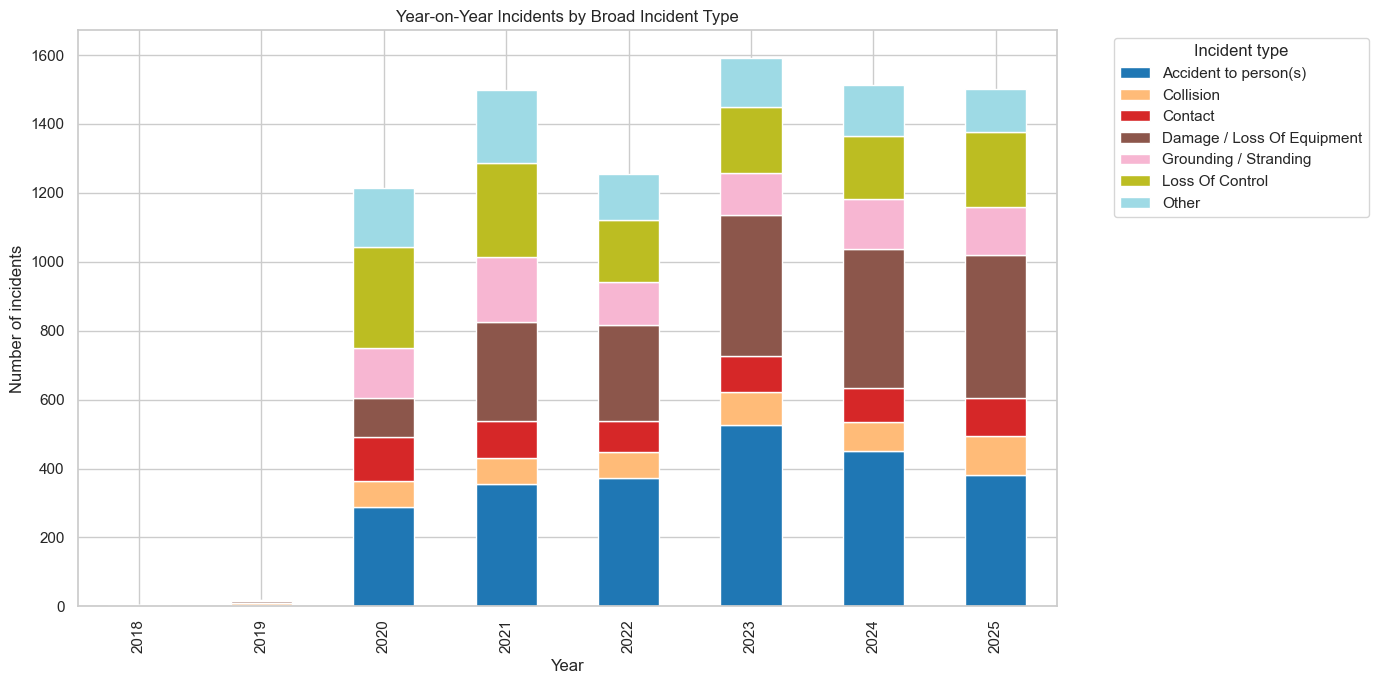

In [21]:
# -----------------------------
# 16. PLOT: STACKED BAR FOR YEARLY INCIDENTS BY TYPE
# -----------------------------
pivot_year_type = year_type_counts.pivot(
    index="event_year",
    columns="main_event_l1_grouped",
    values="count"
).fillna(0)

pivot_year_type.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    colormap="tab20"
)

plt.title("Year-on-Year Incidents by Broad Incident Type")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.legend(title="Incident type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [22]:
# -----------------------------
# 17. SEVERITY BY YEAR
# -----------------------------
severity_by_year = (
    df.dropna(subset=["event_year"])
    .groupby(["event_year", "occurrence_severity"])
    .size()
    .reset_index(name="count")
)

print("\n===== SEVERITY BY YEAR =====")
print(severity_by_year.head(20))


===== SEVERITY BY YEAR =====
    event_year occurrence_severity  count
0         2018        Less Serious      1
1         2018     Marine Incident      2
2         2019        Less Serious      9
3         2019     Marine Incident      8
4         2019        Very Serious      1
5         2020        Less Serious    608
6         2020     Marine Incident    494
7         2020             Serious     81
8         2020        Very Serious     32
9         2021        Less Serious    445
10        2021     Marine Incident    932
11        2021             Serious     75
12        2021        Very Serious     47
13        2022        Less Serious    395
14        2022     Marine Incident    738
15        2022             Serious     70
16        2022        Very Serious     53
17        2023        Less Serious    600
18        2023     Marine Incident    884
19        2023             Serious     47


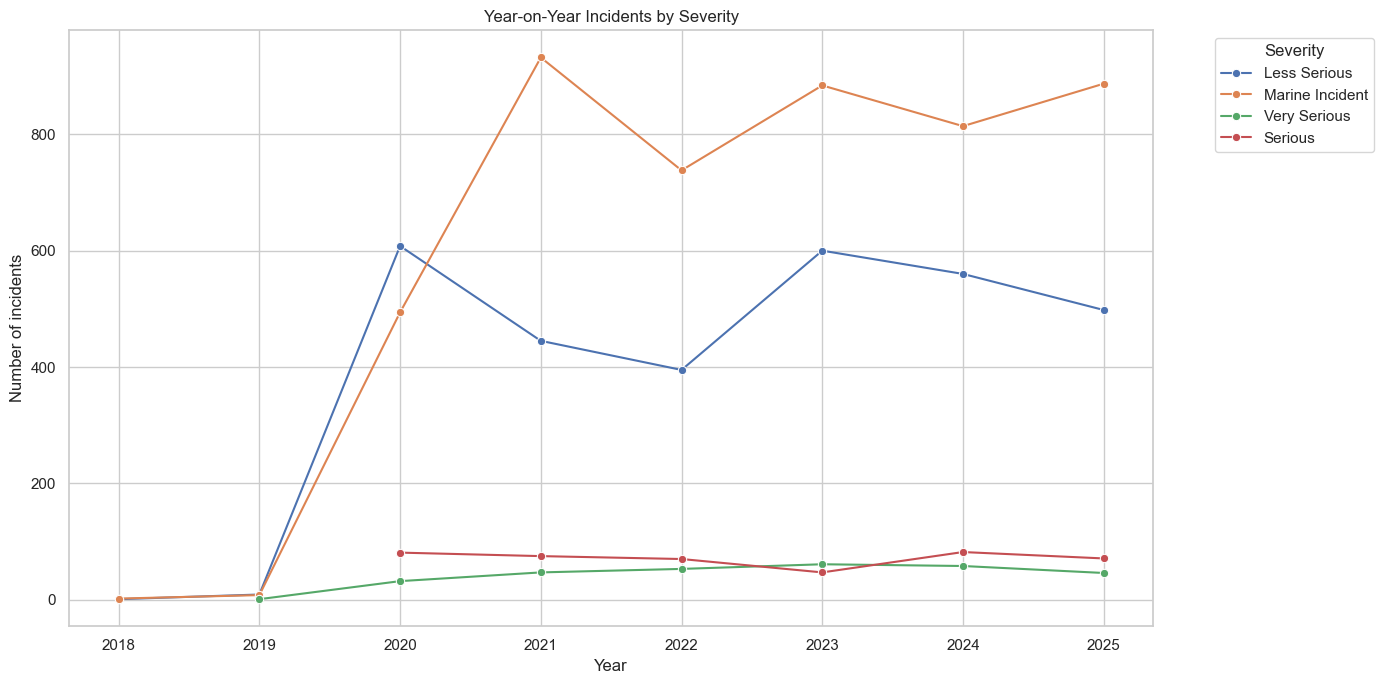

In [23]:
# -----------------------------
# 18. PLOT: SEVERITY BY YEAR
# -----------------------------
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=severity_by_year,
    x="event_year",
    y="count",
    hue="occurrence_severity",
    marker="o"
)

plt.title("Year-on-Year Incidents by Severity")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [24]:
# -----------------------------
# 19. SIMPLE SUMMARY TABLES
# -----------------------------
summary_table = pd.DataFrame({
    "metric": [
        "Total incidents",
        "Earliest event date",
        "Latest event date",
        "Unique years",
        "Unique severity categories",
        "Unique broad incident types"
    ],
    "value": [
        len(df),
        df["local_date_main_event"].min(),
        df["local_date_main_event"].max(),
        df["event_year"].nunique(),
        df["occurrence_severity"].nunique(),
        df["main_event_l1"].nunique()
    ]
})

print("\n===== SUMMARY TABLE =====")
print(summary_table)


===== SUMMARY TABLE =====
                        metric                value
0              Total incidents                 8599
1          Earliest event date  2018-03-01 00:00:00
2            Latest event date  2025-12-01 00:00:00
3                 Unique years                    8
4   Unique severity categories                    4
5  Unique broad incident types                   13


In [25]:
# -----------------------------
# 20. EXPORT OUTPUT TABLES
# -----------------------------
summary_table.to_csv("overview_summary_table.csv", index=False)
missing_summary.to_csv("overview_missing_summary.csv", index=False)
yearly_counts.to_csv("overview_yearly_counts.csv", index=False)
severity_counts.to_csv("overview_severity_counts.csv", index=False)
type_counts.to_csv("overview_type_counts.csv", index=False)
year_type_counts.to_csv("overview_yearly_by_type.csv", index=False)
severity_by_year.to_csv("overview_severity_by_year.csv", index=False)

print("\nCSV outputs saved successfully.")


CSV outputs saved successfully.


In [26]:
# -----------------------------
# 21. NOTEBOOK SUMMARY INSIGHTS
# -----------------------------

total_incidents = len(df)
start_date = df["local_date_main_event"].min()
end_date = df["local_date_main_event"].max()

top_severity = severity_counts.iloc[0]["occurrence_severity"]
top_severity_count = int(severity_counts.iloc[0]["count"])

top_type = type_counts.iloc[0]["main_event_l1"]
top_type_count = int(type_counts.iloc[0]["count"])

first_year = yearly_counts.iloc[0]["event_year"]
first_year_count = int(yearly_counts.iloc[0]["count"])

last_year = yearly_counts.iloc[-1]["event_year"]
last_year_count = int(yearly_counts.iloc[-1]["count"])

trend_direction = "increased" if last_year_count > first_year_count else "decreased"
if last_year_count == first_year_count:
    trend_direction = "remained unchanged"

print("===== OVERVIEW INSIGHTS =====")
print(f"1. The dataset contains {total_incidents} reported incidents covering the period from {start_date.date()} to {end_date.date()}.")
print(f"2. The most common severity category is '{top_severity}' with {top_severity_count} incidents.")
print(f"3. The most common broad incident type is '{top_type}' with {top_type_count} incidents.")
print(f"4. Reported incidents {trend_direction} from {first_year_count} in {int(first_year)} to {last_year_count} in {int(last_year)}.")
print("5. Use the year-by-type chart to comment on whether the mix of broad incident categories changes over time.")

===== OVERVIEW INSIGHTS =====
1. The dataset contains 8599 reported incidents covering the period from 2018-03-01 to 2025-12-01.
2. The most common severity category is 'Marine Incident' with 4759 incidents.
3. The most common broad incident type is 'Accident to person(s)' with 2381 incidents.
4. Reported incidents increased from 3 in 2018 to 1502 in 2025.
5. Use the year-by-type chart to comment on whether the mix of broad incident categories changes over time.
